# 03 af architecture - within-gene af shuffle null

## hypothesis

rare-variant enrichment in clingen hi genes exceeds what we would expect by chance if af values were randomly reassigned across variants within each gene

## null design

for each gene:
- keep the set of observed af values fixed
- keep variant scores fixed
- shuffle af values across that gene's variants
- recalculate `vg_predicted`, `vg_rare`, `vg_common`, and `rare_fraction`
- repeat `100` times per gene

## primary test

compare the observed difference in median `rare_fraction` between `clingen` and `background` against the permutation-based null distribution


In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150


def _resolve_project_root() -> Path:
    """resolve the project root from the current working directory.

    args:
        none

    returns:
        Path: resolved project root.

    raises:
        FileNotFoundError: when `config.py` cannot be found.
    """
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')


PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import DISPLAY_NAMES, SOURCE_PALETTE, VARIANT_PATHS, VG_MIN_CLIP
from utils.plot_utils import autosave

NOTEBOOK_NAME = '03_af_architecture_within_gene_af_shuffle_null'
AF_THRESHOLD = 0.05
N_PERM = 100
RNG_SEED = 42

print(f'project root: {PROJECT_ROOT}')
print(f'af threshold: {AF_THRESHOLD}')
print(f'permutations per gene: {N_PERM}')
print(f'rng seed: {RNG_SEED}')
for dataset_name in ['background', 'clingen']:
    print(f'{dataset_name}: {VARIANT_PATHS[dataset_name].name}')


project root: /Users/markus/in-silico-vg-analysis
af threshold: 0.05
permutations per gene: 100
rng seed: 42
background: Background_Gnomad_variants_dedup_perm_21022026.parquet
clingen: ClinGen_HI_Gnomad_variants_dedup_21022026.parquet


In [7]:
def load_real_variants(dataset_name: str) -> pl.DataFrame:
    """load and deduplicate real variants for af-shuffle analysis.

    args:
        dataset_name (str): real dataset key. must be `background` or `clingen`.

    returns:
        pl.DataFrame: deduplicated variants with af, score, gene id, and source.

    raises:
        ValueError: when the dataset is not supported.
    """
    if dataset_name not in {'background', 'clingen'}:
        raise ValueError(f'unsupported real dataset: {dataset_name}')

    df = pl.read_parquet(VARIANT_PATHS[dataset_name])

    if 'gene_symbol' in df.columns:
        symbol_expr = pl.col('gene_symbol')
    elif 'gene_name' in df.columns:
        symbol_expr = pl.col('gene_name').alias('gene_symbol')
    else:
        symbol_expr = pl.lit(None).cast(pl.String).alias('gene_symbol')

    variant_df = (
        df
        .select([
            pl.col('variant_id'),
            pl.col('gene_id'),
            symbol_expr,
            pl.col('raw_score'),
            pl.col('AF'),
        ])
        .drop_nulls(['variant_id', 'gene_id', 'raw_score', 'AF'])
        .filter((pl.col('AF') >= 0) & (pl.col('AF') <= 1))
        .with_columns(pl.col('raw_score').abs().alias('_abs_score'))
        .sort('_abs_score', descending=True)
        .unique(subset=['variant_id'], keep='first')
        .drop('_abs_score')
        .with_columns(pl.lit(dataset_name).alias('source'))
    )

    return variant_df


def _compute_gene_stats(
    af_values: np.ndarray,
    score_sq: np.ndarray,
    af_threshold: float = AF_THRESHOLD,
) -> dict[str, float]:
    """compute per-gene vg summary statistics.

    args:
        af_values (np.ndarray): af values aligned to the score vector.
        score_sq (np.ndarray): squared variant scores.
        af_threshold (float): threshold separating rare from common af.

    returns:
        dict[str, float]: total, rare, common, and rare fraction summaries.
    """
    weights = 2.0 * af_values * (1.0 - af_values)
    contributions = weights * score_sq
    rare_mask = af_values < af_threshold

    vg_rare = float(contributions[rare_mask].sum())
    vg_common = float(contributions[~rare_mask].sum())
    vg_total = float(contributions.sum())
    rare_fraction = vg_rare / vg_total if vg_total > 0 else np.nan

    return {
        'vg_predicted': vg_total,
        'vg_rare': vg_rare,
        'vg_common': vg_common,
        'rare_fraction': rare_fraction,
        'n_rare_variants': int(rare_mask.sum()),
        'n_common_variants': int((~rare_mask).sum()),
    }


def run_within_gene_af_shuffle(
    grouped_variants: pl.DataFrame,
    n_perm: int = N_PERM,
    rng_seed: int = RNG_SEED,
    af_threshold: float = AF_THRESHOLD,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """run within-gene af-shuffle permutations and collect gene-level summaries.

    args:
        grouped_variants (pl.DataFrame): grouped per-gene variant arrays.
        n_perm (int): number of permutations per gene.
        rng_seed (int): seed for the random generator.
        af_threshold (float): threshold separating rare from common af.

    returns:
        tuple[pd.DataFrame, pd.DataFrame]: observed and permuted gene-level summaries.
    """
    rng = np.random.default_rng(rng_seed)
    observed_rows: list[dict[str, object]] = []
    perm_rows: list[dict[str, object]] = []

    for row in tqdm(
        grouped_variants.iter_rows(named=True),
        total=grouped_variants.height,
        desc='within-gene af shuffles',
    ):
        af_values = np.asarray(row['af_values'], dtype=float)
        score_sq = np.square(np.asarray(row['score_values'], dtype=float))
        weights = 2.0 * af_values * (1.0 - af_values)
        rare_mask = af_values < af_threshold

        base = {
            'source': row['source'],
            'gene_id': row['gene_id'],
            'gene_symbol': row['gene_symbol'],
            'n_variants': row['n_variants'],
        }
        observed_rows.append(base | _compute_gene_stats(af_values, score_sq, af_threshold))

        for perm_idx in range(n_perm):
            perm_order = rng.permutation(af_values.size)
            perm_contrib = weights[perm_order] * score_sq
            perm_rare_mask = rare_mask[perm_order]
            vg_total = float(perm_contrib.sum())
            vg_rare = float(perm_contrib[perm_rare_mask].sum())
            vg_common = float(perm_contrib[~perm_rare_mask].sum())

            perm_rows.append(
                base | {
                    'perm_idx': perm_idx,
                    'vg_predicted': vg_total,
                    'vg_rare': vg_rare,
                    'vg_common': vg_common,
                    'rare_fraction': vg_rare / vg_total if vg_total > 0 else np.nan,
                }
            )

    return pd.DataFrame(observed_rows), pd.DataFrame(perm_rows)


In [8]:
bg_variants = load_real_variants('background')
hi_variants = load_real_variants('clingen')
variant_df = pl.concat([bg_variants, hi_variants], how='diagonal_relaxed')

grouped_variants = (
    variant_df
    .group_by(['source', 'gene_id'])
    .agg([
        pl.col('gene_symbol').drop_nulls().first().alias('gene_symbol'),
        pl.col('AF').alias('af_values'),
        pl.col('raw_score').alias('score_values'),
        pl.len().alias('n_variants'),
    ])
    .sort(['source', 'gene_id'])
)

print(f'background variants after dedup: {bg_variants.height:,}')
print(f'clingen variants after dedup: {hi_variants.height:,}')
print(f'total grouped genes: {grouped_variants.height:,}')
print(grouped_variants.group_by('source').agg(pl.len().alias('n_genes')).sort('source'))


background variants after dedup: 1,461,051
clingen variants after dedup: 1,446,657
total grouped genes: 665
shape: (2, 2)
┌────────────┬─────────┐
│ source     ┆ n_genes │
│ ---        ┆ ---     │
│ str        ┆ u32     │
╞════════════╪═════════╡
│ background ┆ 349     │
│ clingen    ┆ 316     │
└────────────┴─────────┘


In [9]:
observed_gene_stats, perm_gene_stats = run_within_gene_af_shuffle(grouped_variants)

observed_gene_stats['display_name'] = observed_gene_stats['gene_symbol'].fillna(observed_gene_stats['gene_id'])

observed_source_summary = (
    observed_gene_stats
    .groupby('source', as_index=False)
    .agg(
        n_genes=('gene_id', 'nunique'),
        median_rare_fraction=('rare_fraction', 'median'),
        median_vg_rare=('vg_rare', 'median'),
        median_vg_common=('vg_common', 'median'),
    )
)
observed_source_summary['display_name'] = observed_source_summary['source'].map(DISPLAY_NAMES)

perm_source_medians = (
    perm_gene_stats
    .groupby(['perm_idx', 'source'], as_index=False)
    .agg(median_rare_fraction=('rare_fraction', 'median'))
    .pivot(index='perm_idx', columns='source', values='median_rare_fraction')
    .reset_index()
)
perm_source_medians['delta_hi_minus_bg'] = (
    perm_source_medians['clingen'] - perm_source_medians['background']
)

obs_hi = observed_gene_stats.loc[
    observed_gene_stats['source'] == 'clingen',
    'rare_fraction',
].dropna().values
obs_bg = observed_gene_stats.loc[
    observed_gene_stats['source'] == 'background',
    'rare_fraction',
].dropna().values
obs_delta = float(np.median(obs_hi) - np.median(obs_bg))
null_delta = perm_source_medians['delta_hi_minus_bg'].to_numpy(dtype=float)
empirical_p = (float(np.sum(null_delta >= obs_delta)) + 1.0) / (len(null_delta) + 1.0)

mw_u, mw_p = stats.mannwhitneyu(obs_hi, obs_bg, alternative='greater')
null_mean = float(null_delta.mean())
null_sd = float(null_delta.std(ddof=0))
null_z = (obs_delta - null_mean) / null_sd if null_sd > 0 else np.nan

result_summary = pd.DataFrame([
    {
        'metric': 'median rare_fraction delta (HI - BG)',
        'observed': obs_delta,
        'null_mean': null_mean,
        'null_sd': null_sd,
        'null_p95': float(np.percentile(null_delta, 95)),
        'empirical_p': empirical_p,
        'mann_whitney_u': float(mw_u),
        'mann_whitney_p': float(mw_p),
        'z_like': null_z,
    }
])

print('observed source summary')
print(observed_source_summary[['display_name', 'n_genes', 'median_rare_fraction', 'median_vg_rare', 'median_vg_common']].to_string(index=False, float_format=lambda x: f'{x:.4g}'))
print('\nprimary null test')
print(result_summary.to_string(index=False, float_format=lambda x: f'{x:.4g}'))


within-gene af shuffles:   0%|          | 0/665 [00:00<?, ?it/s]

observed source summary
display_name  n_genes  median_rare_fraction  median_vg_rare  median_vg_common
  Background      349                0.2074       0.0006221          0.002189
  ClinGen HI      316                 0.255        0.000479          0.001359

primary null test
                              metric  observed  null_mean  null_sd  null_p95  empirical_p  mann_whitney_u  mann_whitney_p  z_like
median rare_fraction delta (HI - BG)   0.04762   0.007106  0.01756   0.03564       0.0198        6.14e+04        0.005715   2.307


/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_55584/1061449070.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_55584/1061449070.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


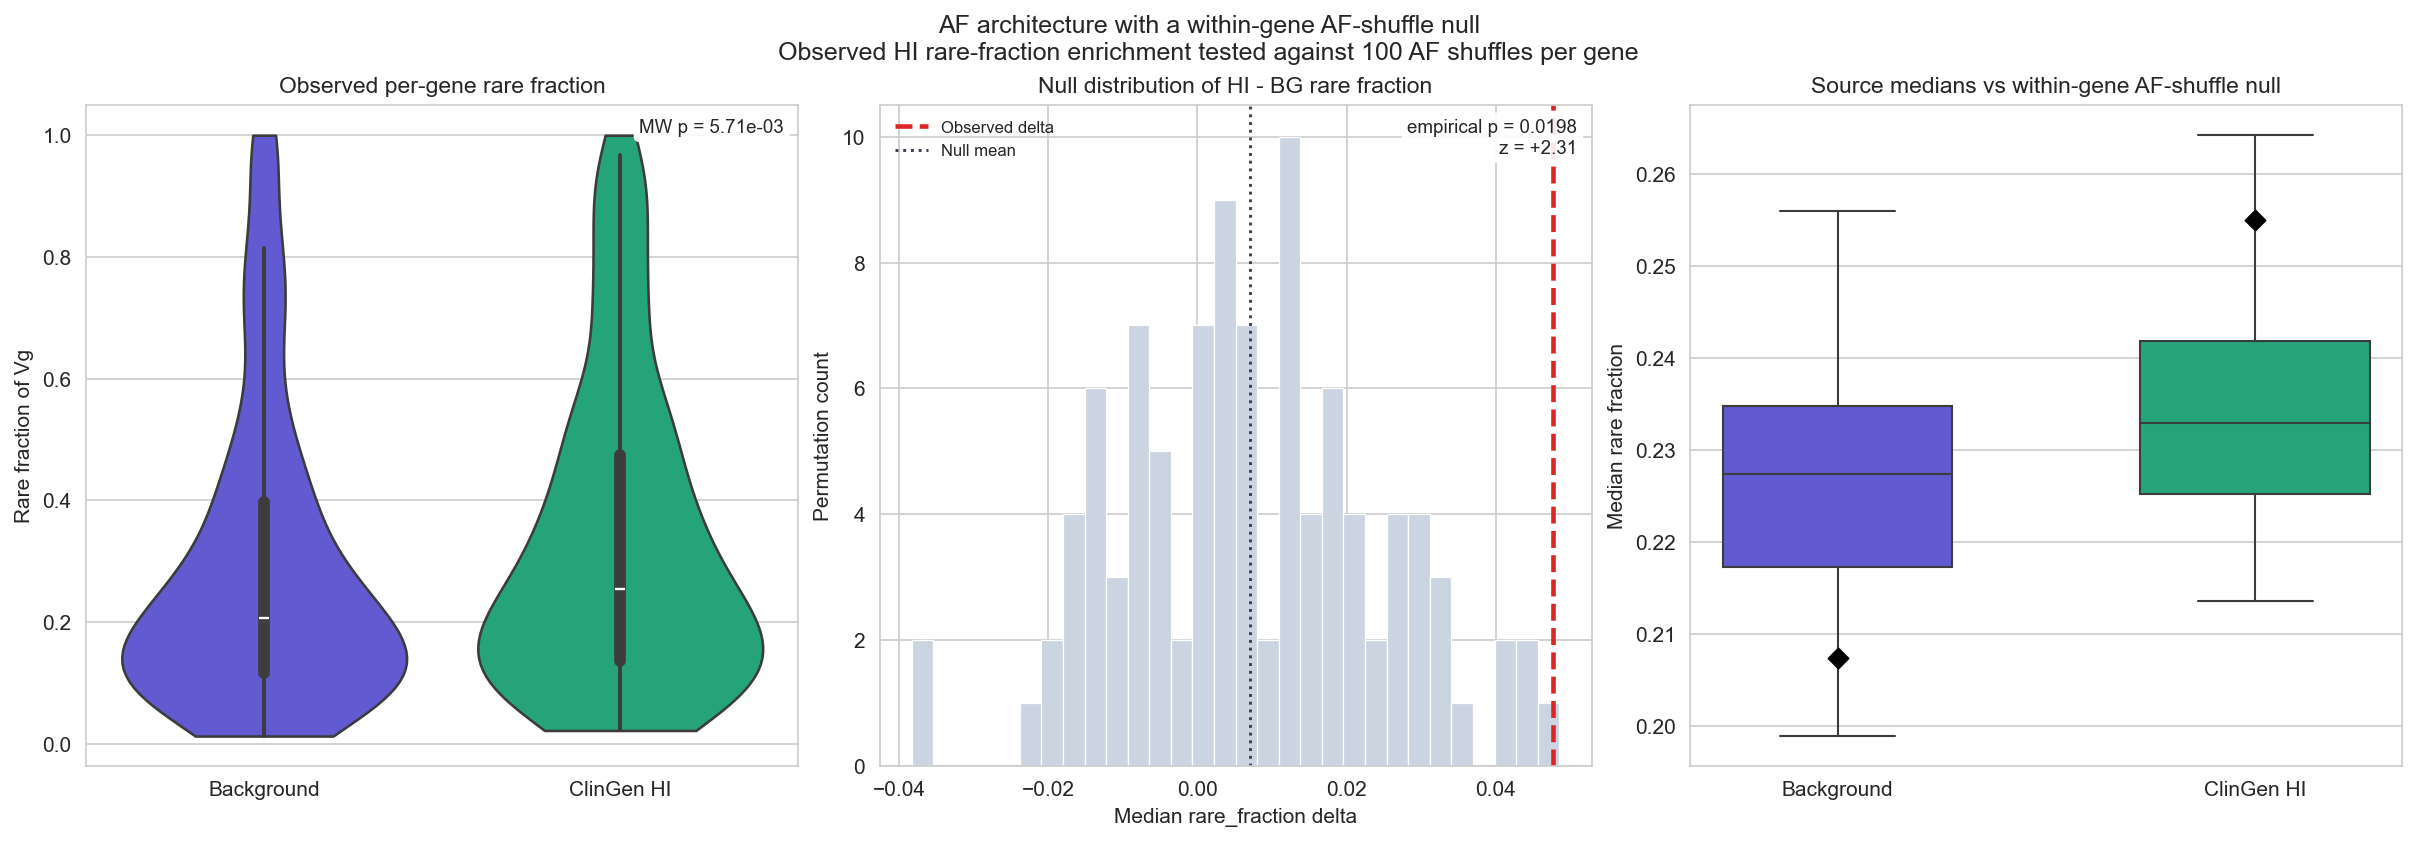

[save_plot] Saved: 03_af_architecture_within_gene_af_shuffle_null_AF_architecture_within_gene_af_shuffle_primary_null_25032026_1533.pdf
[save_plot] Saved: 03_af_architecture_within_gene_af_shuffle_null_AF_architecture_within_gene_af_shuffle_primary_null_25032026_1533.svg


<Figure size 960x720 with 0 Axes>

In [10]:
plot_obs = observed_gene_stats.copy()
plot_obs['label'] = plot_obs['source'].map(DISPLAY_NAMES)
plot_perm = perm_source_medians.melt(
    id_vars='perm_idx',
    value_vars=['background', 'clingen'],
    var_name='source',
    value_name='median_rare_fraction',
)
plot_perm['label'] = plot_perm['source'].map(DISPLAY_NAMES)
plot_order = [DISPLAY_NAMES['background'], DISPLAY_NAMES['clingen']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), constrained_layout=True)

with autosave('AF_architecture_within_gene_af_shuffle_primary_null', notebook=NOTEBOOK_NAME):
    ax = axes[0]
    sns.violinplot(
        data=plot_obs,
        x='label',
        y='rare_fraction',
        order=plot_order,
        palette=[SOURCE_PALETTE['background'], SOURCE_PALETTE['clingen']],
        cut=0,
        inner='box',
        ax=ax,
    )
    ax.set_title('Observed per-gene rare fraction', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Rare fraction of Vg', fontsize=10)
    ax.text(
        0.98,
        0.98,
        f'MW p = {mw_p:.2e}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.90),
    )

    ax = axes[1]
    ax.hist(null_delta, bins=30, color='#cbd5e1', edgecolor='white', linewidth=0.6)
    ax.axvline(obs_delta, color='#dc2626', lw=2.2, ls='--', label='Observed delta')
    ax.axvline(null_mean, color='#374151', lw=1.4, ls=':', label='Null mean')
    ax.set_title('Null distribution of HI - BG rare fraction', fontsize=11)
    ax.set_xlabel('Median rare_fraction delta', fontsize=10)
    ax.set_ylabel('Permutation count', fontsize=10)
    ax.legend(frameon=False, fontsize=8)
    ax.text(
        0.98,
        0.98,
        f'empirical p = {empirical_p:.3g}\nz = {null_z:+.2f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.90),
    )

    ax = axes[2]
    sns.boxplot(
        data=plot_perm,
        x='label',
        y='median_rare_fraction',
        order=plot_order,
        palette=[SOURCE_PALETTE['background'], SOURCE_PALETTE['clingen']],
        width=0.55,
        showfliers=False,
        ax=ax,
    )
    for xpos, source_name in enumerate(['background', 'clingen']):
        observed_value = observed_source_summary.loc[
            observed_source_summary['source'] == source_name,
            'median_rare_fraction',
        ].iloc[0]
        ax.scatter(
            xpos,
            observed_value,
            color='black',
            s=45,
            marker='D',
            zorder=4,
        )
    ax.set_title('Source medians vs within-gene AF-shuffle null', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Median rare fraction', fontsize=10)

    fig.suptitle(
        'AF architecture with a within-gene AF-shuffle null\n'
        'Observed HI rare-fraction enrichment tested against 100 AF shuffles per gene',
        fontsize=12,
    )
    plt.show()
